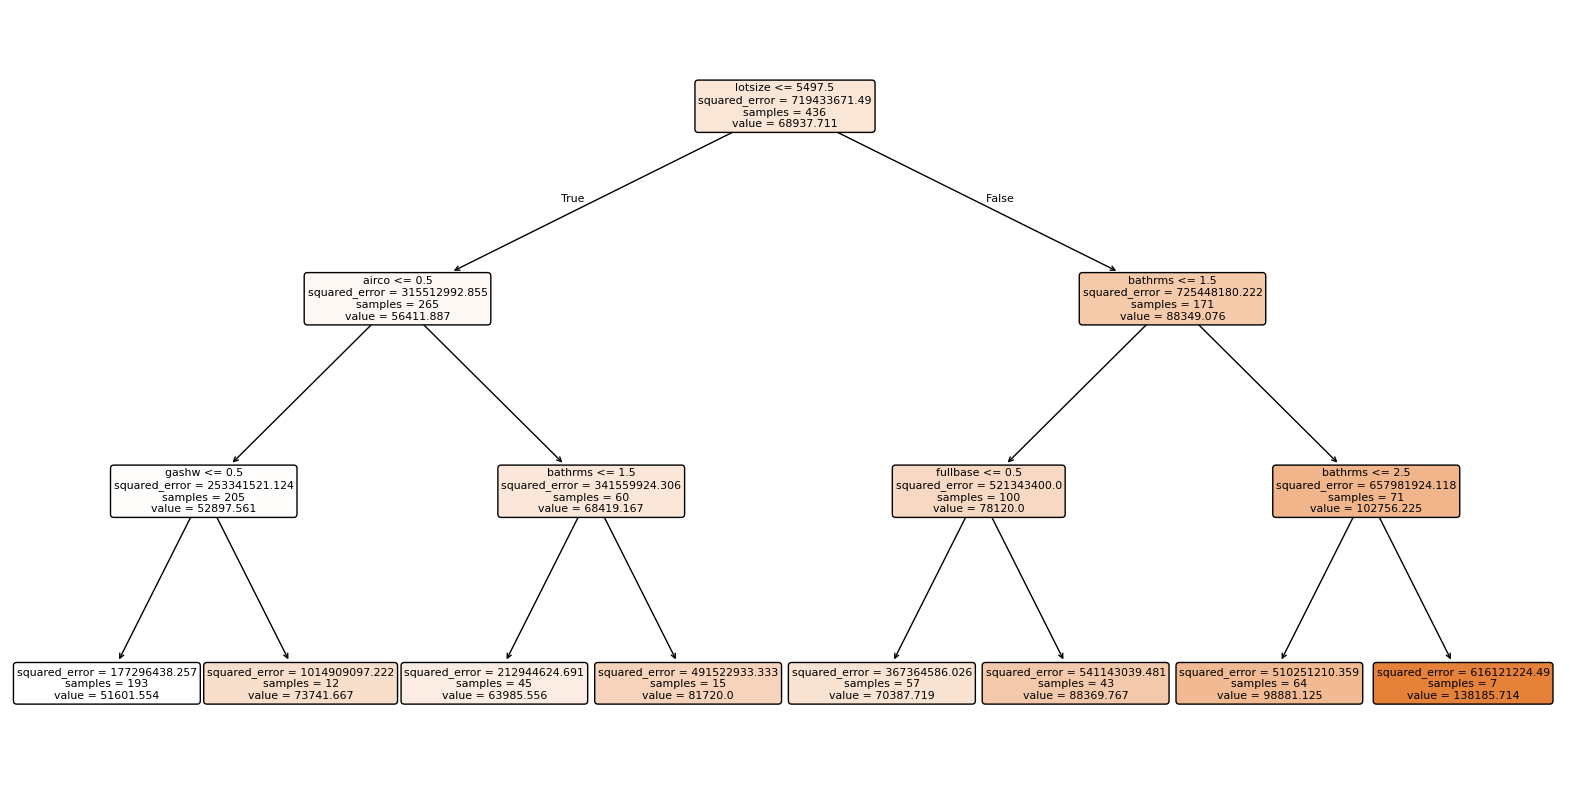

Середньоквадратична помилка (MSE): 386033683.20


In [4]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

data = pd.read_csv("housing.csv")
data.head()

binary_cols = ['driveway', 'recroom', 'fullbase', 'gashw', 'airco', 'prefarea']
for col in binary_cols:
    data[col] = data[col].map({'yes': 1, 'no': 0})

X = data.drop(columns=['rownames', 'price'])
y = data['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeRegressor(max_depth=3, random_state=42)
model.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=X.columns, filled=True, rounded=True)
plt.show()

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Середньоквадратична помилка (MSE): {mse:.2f}")

In [6]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

df = pd.read_csv('housing.csv')

df = df.drop(columns=['rownames'])
df = df.replace({'yes': 1, 'no': 0})

df['high_price'] = (df['price'] > df['price'].mean()).astype(int)

X = df.drop(columns=['price', 'high_price'])
y = df['high_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Точність моделі:", accuracy)


C:\Users\User\AppData\Local\Temp\ipykernel_14992\4280622736.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({'yes': 1, 'no': 0})


Точність моделі: 0.8292682926829268


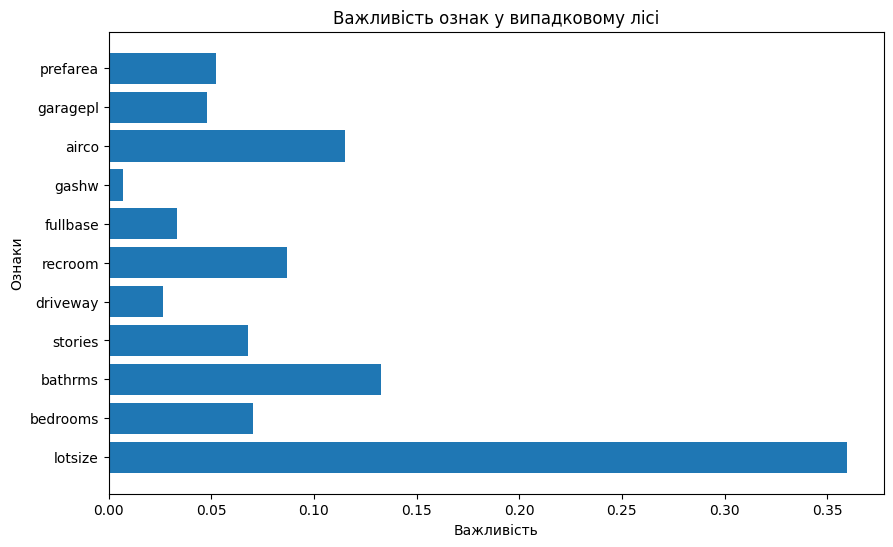

In [7]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(10, 6))
plt.barh(features, importances)
plt.xlabel('Важливість')
plt.ylabel('Ознаки')
plt.title('Важливість ознак у випадковому лісі')
plt.show()


In [8]:
# !pip install xgboost
import xgboost as xgb
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBClassifier(
    objective='multi:softmax',  
    num_class=3,                
    max_depth=3,               
    learning_rate=0.1,          
    n_estimators=100           
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.3f}')

Accuracy: 1.000


Confusion matrix:
[[68  7]
 [ 8 67]]
Precision: 0.905
Recall: 0.893
F1 score: 0.899


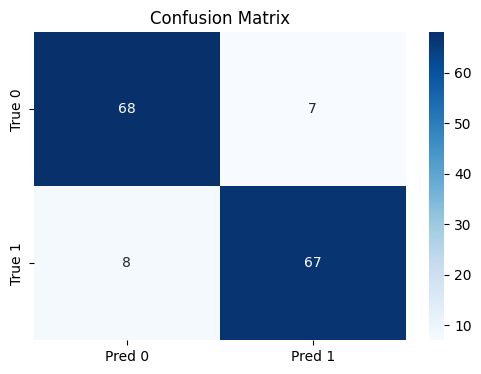

In [9]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

X, y = make_classification(n_samples=500, n_features=5, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Confusion matrix:\n{cm}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1 score: {f1:.3f}')

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred 0','Pred 1'], yticklabels=['True 0','True 1'])
plt.title('Confusion Matrix')
plt.show()


In [10]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X = np.array([
    [25, 40, 0],
    [30, 60, 1],
    [22, 35, 0],
    [35, 70, 1],
    [28, 50, 0],
    [40, 80, 1],
    [23, 45, 0],
    [50, 90, 1],
    [48, 85, 1],
    [33, 65, 0]
])

y = np.array([0, 1, 0, 1, 0, 1, 0, 1, 1, 0])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2

